In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df = pd.read_csv("data/dataset_financier_clean.csv")
df.head()

,bilan_financier,actifs,revenu,depenses,taux_interet,flux_tresorerie,capital,agence_freq,banque_freq,lieu_freq
0,57450.712295,29795.488056,2459.857380,546.096221,4.850180,9549.649146,36581.956747,0.323,0.238,0.266
1,47926.035482,26472.435780,2884.385063,1069.807495,0.854030,6207.981496,38725.670920,0.323,0.260,0.251
2,59715.328072,20417.412589,2366.064063,1293.197233,9.724614,11458.554375,77179.593209,0.342,0.260,0.266
3,72845.447846,15471.442556,2753.630776,2443.843829,5.180104,4151.884734,36901.898344,0.323,0.260,0.251
4,46487.699379,24887.563195,1485.108266,1778.276562,6.141862,3848.927628,46121.492335,0.323,0.251,0.266


<a id="5"></a>
# <p style="background-image: url(https://i.postimg.cc/3x3hj8VY/pngtree-colorful-pastel-gradient-background-texture-in-shades-of-pink-purple-blue-image-16381316.jpg);font-family:newtimeroman;font-size:120%;color:black;text-align:center;border-radius:15px 50px; padding:7px">I. ANN Building</p>

<a class="btn" href="#home">📅 ANN Constructing</a>

In [6]:
# importation des librairies
import tensorflow as tf
print(tf.__version__)

2.20.0


In [7]:
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense,BatchNormalization, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform, randint
from scikeras.wrappers import KerasRegressor



In [8]:
# séparer X et Y
X = df.drop('depenses', axis=1)
y = df['depenses']

In [9]:
# spliter X_train et x-test
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [10]:
# standardisation de X_train X_test, Y-train et Y-test
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [11]:
# je veux voir la taille de mon dataset
df.shape

(1000, 10)

In [12]:
# Fonction pour créer le modèle
def create_model(neurons=64, learning_rate=0.001, dropout_rate=0.2, layers=2):
    model = Sequential()
    
    # Première couche
    model.add(Dense(neurons, activation='relu', input_dim=X_train.shape[1]))
    model.add(Dropout(dropout_rate))
    
    # Couches cachées supplémentaires
    for _ in range(layers - 1):
        model.add(Dense(neurons // 2, activation='relu'))
        model.add(Dropout(dropout_rate))
        neurons = neurons // 2
    
    # Couche de sortie
    model.add(Dense(1, activation='linear'))
    
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss='mse',
        metrics=['mse']
    )
    return model

# Wrapper
model = KerasRegressor(
    model=create_model,
    verbose=0
)

# Paramètres à tester
param_distributions = {
    'model__neurons': [32, 64, 128],
    'model__learning_rate': [0.0001, 0.001, 0.01],
    'model__dropout_rate': [0.2, 0.3, 0.4],
    'model__layers': [2, 3],
    'batch_size': [32, 64],
    'epochs': [100, 150, 200]
}

# Random Search
random_search = RandomizedSearchCV(
    estimator=model,
    param_distributions=param_distributions,
    n_iter=15,  # 15 combinaisons testées
    cv=3,
    scoring='neg_mean_squared_error',
    verbose=2,
    random_state=42,
    n_jobs=1  # Mettre à -1 si vous avez plusieurs CPU
)

In [13]:
print("Début du Random Search...")
random_search.fit(X_train, y_train)

# Résultats
print("\n" + "="*60)
print("RÉSULTATS DU RANDOM SEARCH")
print("="*60)
print(f"\nMeilleurs paramètres:")
for param, value in random_search.best_params_.items():
    print(f"  {param}: {value}")

print(f"\nMeilleur score (MSE): {-random_search.best_score_:.4f}")

Début du Random Search...
Fitting 3 folds for each of 15 candidates, totalling 45 fits


e:\M2_s1\all_environements\ml_env1\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


[CV] END batch_size=32, epochs=200, model__dropout_rate=0.3, model__layers=2, model__learning_rate=0.01, model__neurons=32; total time=  18.4s


e:\M2_s1\all_environements\ml_env1\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


[CV] END batch_size=32, epochs=200, model__dropout_rate=0.3, model__layers=2, model__learning_rate=0.01, model__neurons=32; total time=  12.4s


...

[CV] END batch_size=64, epochs=100, model__dropout_rate=0.3, model__layers=2, model__learning_rate=0.01, model__neurons=32; total time=   5.6s


e:\M2_s1\all_environements\ml_env1\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


[CV] END batch_size=64, epochs=100, model__dropout_rate=0.3, model__layers=2, model__learning_rate=0.01, model__neurons=32; total time=   6.0s


e:\M2_s1\all_environements\ml_env1\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



RÉSULTATS DU RANDOM SEARCH

Meilleurs paramètres:
  model__neurons: 32
  model__learning_rate: 0.01
  model__layers: 2
  model__dropout_rate: 0.3
  epochs: 200
  batch_size: 32

Meilleur score (MSE): 286581.9159


In [14]:
# Entraîner le meilleur modèle
best_model = random_search.best_estimator_

In [15]:
score = best_model.score(X_test, y_test)
print(f"R² sur test set: {score:.4f}")

R² sur test set: -0.0666


In [144]:
# Build model
"""nous allons rajouter Dropout pour éviter le overfit en éteignant aléatoirement des neurones pendant l’entraînement
"""
model = Sequential()
model.add(Dense(32, activation='relu', input_shape=(X_train.shape[1],)))
model.add(Dropout(0.2))
model.add(Dense(16, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(8, activation='relu'))
model.add(Dense(1, activation='linear'))

e:\M2_s1\all_environements\ml_env1\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [145]:
# resumé du model
model.summary()

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_38 (Dense)                │ (None, 32)             │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_22 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_39 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_23 (Dropout)            │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_40 (Dense)                │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_41 (Dense)                │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 993 (3.88 KB)

 Trainable params: 993 (3.88 KB)

 Non-trainable params: 0 (0.00 B)

In [146]:
# Compilation
model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mse']
)


In [147]:
"""restore_best_weights restaure automatiquement,
    les poids du modèle correspondant à l'epoch qui avait la meilleure performance sur val_loss"""
# Callbacks
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=30,
    restore_best_weights=True, 
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    patience=10,
    min_lr=0.001,
    verbose=1
)

checkpoint = ModelCheckpoint(
    filepath='best_model.h5',
    monitor='val_loss',
    save_best_only=True,
    mode='min', # Sauvegarde quand val_loss DIMINUE
    verbose=1
)

In [148]:
# Entraînement avec tous les callbacks
history = model.fit(
    X_train, y_train,
    epochs=300,
    batch_size=32,
    validation_split=0.2, #pour la validation pendant le training
    callbacks=[early_stop, reduce_lr, checkpoint],
    verbose=1
)

Epoch 1/300
 1/20 ━━━━━━━━━━━━━━━━━━━━ 18s 981ms/step - loss: 2393978.0000 - mse: 2393978.0000
Epoch 1: val_loss improved from None to 2598649.50000, saving model to best_model.h5


20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 2442441.5000 - mse: 2442441.5000 - val_loss: 2598649.5000 - val_mse: 2598649.5000 - learning_rate: 0.0010
Epoch 2/300
 1/20 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 2570769.0000 - mse: 2570769.0000
Epoch 2: val_loss improved from 2598649.50000 to 2596750.00000, saving model to best_model.h5


20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 2440871.7500 - mse: 2440871.7500 - val_loss: 2596750.0000 - val_mse: 2596750.0000 - learning_rate: 0.0010
Epoch 3/300
 1/20 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 2366540.0000 - mse: 2366540.0000
Epoch 3: val_loss improved from 2596750.00000 to 2593327.25000, saving model to best_model.h5


20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 2438294.7500 - mse: 2438294.7500 - val_loss: 2593327.2500 - val_mse: 2593327.2500 - learning_rate: 0.0010
Epoch 4/300
 1/20 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 2382018.5000 - mse: 2382018.5000
Epoch 4: val_loss improved from 2593327.25000 to 2586678.75000, saving model to best_model.h5


20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 2433754.7500 - mse: 2433754.7500 - val_loss: 2586678.7500 - val_mse: 2586678.7500 - learning_rate: 0.0010
Epoch 5/300
 1/20 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 2656295.5000 - mse: 2656295.5000
Epoch 5: val_loss improved from 2586678.75000 to 2573270.75000, saving model to best_model.h5


...

20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 312648.2500 - mse: 312648.2500 - val_loss: 301442.2500 - val_mse: 301442.2500 - learning_rate: 0.0010
Epoch 131/300
 1/20 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 289010.8125 - mse: 289010.8125
Epoch 131: val_loss did not improve from 301442.25000
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 327060.5000 - mse: 327060.5000 - val_loss: 303199.5938 - val_mse: 303199.5938 - learning_rate: 0.0010
Epoch 132/300
 1/20 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 328484.5000 - mse: 328484.5000
Epoch 132: val_loss did not improve from 301442.25000
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 312609.9375 - mse: 312609.9375 - val_loss: 302243.0000 - val_mse: 302243.0000 - learning_rate: 0.0010
Epoch 133/300
 1/20 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 269197.7812 - mse: 269197.7812
Epoch 133: val_loss did not improve from 301442.25000
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 314847.5625 - mse: 314847.5625 - val_loss: 302554.0312 - val_mse:

20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 315391.3438 - mse: 315391.3438 - val_loss: 301060.7188 - val_mse: 301060.7188 - learning_rate: 0.0010
Epoch 148/300
 1/20 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 337395.7188 - mse: 337395.7188
Epoch 148: val_loss improved from 301060.71875 to 300346.31250, saving model to best_model.h5


20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 304816.6875 - mse: 304816.6875 - val_loss: 300346.3125 - val_mse: 300346.3125 - learning_rate: 0.0010
Epoch 149/300
 1/20 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 244859.5938 - mse: 244859.5938
Epoch 149: val_loss improved from 300346.31250 to 299226.96875, saving model to best_model.h5


20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 308957.0938 - mse: 308957.0938 - val_loss: 299226.9688 - val_mse: 299226.9688 - learning_rate: 0.0010
Epoch 150/300
 1/20 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 358026.8125 - mse: 358026.8125
Epoch 150: val_loss did not improve from 299226.96875
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 330884.6250 - mse: 330884.6250 - val_loss: 303040.0312 - val_mse: 303040.0312 - learning_rate: 0.0010
Epoch 151/300
 1/20 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 158473.0312 - mse: 158473.0312
Epoch 151: val_loss did not improve from 299226.96875
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 319955.0000 - mse: 319955.0000 - val_loss: 301131.4062 - val_mse: 301131.4062 - learning_rate: 0.0010
Epoch 152/300
 1/20 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 252719.0625 - mse: 252719.0625
Epoch 152: val_loss did not improve from 299226.96875
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 323982.5938 - mse: 323982.5938 - val_loss: 301900.8125 - val_mse:

20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 297833.5000 - mse: 297833.5000 - val_loss: 298680.7812 - val_mse: 298680.7812 - learning_rate: 0.0010
Epoch 156/300
 1/20 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 246795.5625 - mse: 246795.5625
Epoch 156: val_loss did not improve from 298680.78125
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 286537.2812 - mse: 286537.2812 - val_loss: 300114.1562 - val_mse: 300114.1562 - learning_rate: 0.0010
Epoch 157/300
 1/20 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 247431.0938 - mse: 247431.0938
Epoch 157: val_loss did not improve from 298680.78125
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 332450.7188 - mse: 332450.7188 - val_loss: 302184.5938 - val_mse: 302184.5938 - learning_rate: 0.0010
Epoch 158/300
 1/20 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 307428.6875 - mse: 307428.6875
Epoch 158: val_loss did not improve from 298680.78125
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 310645.1562 - mse: 310645.1562 - val_loss: 301573.3125 - val_mse:

In [149]:
# quelles sont les critères d'évaluation de mon training
print(history.history.keys())

dict_keys(['loss', 'mse', 'val_loss', 'val_mse', 'learning_rate'])


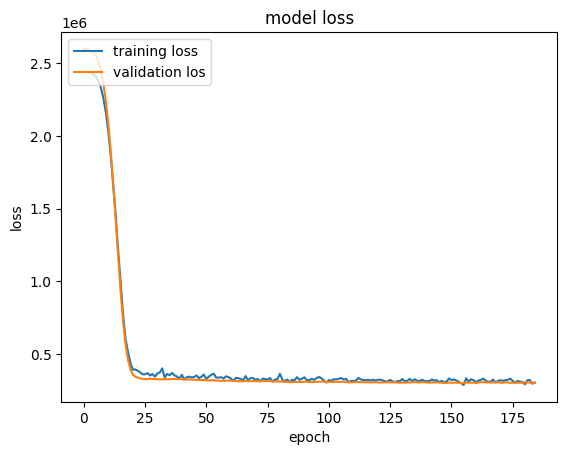

<module 'matplotlib.pyplot' from 'e:\\M2_s1\\all_environements\\ml_env1\\lib\\site-packages\\matplotlib\\pyplot.py'>

In [150]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['training loss', 'validation los'], loc='upper left')
plt.show()
plt

<a id="5"></a>
# <p style="background-image: url(https://i.postimg.cc/3x3hj8VY/pngtree-colorful-pastel-gradient-background-texture-in-shades-of-pink-purple-blue-image-16381316.jpg);font-family:newtimeroman;font-size:120%;color:black;text-align:center;border-radius:15px 50px; padding:7px">III. ANN Evaluating</p>

<a class="btn" href="#home">📅 ANN Evaluating</a>

In [151]:
#Prediction
y_pred_train = model.predict(X_train)
y_pred_train

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 733us/step


array([[1515.1428],
       [1665.4604],
       [1647.7262],
       [1531.5946],
       [1899.1481],
       [1291.3303],
       [1372.2417],
       [1389.0999],
       [1344.1323],
       [1592.1482],
       [1425.8462],
       [1371.429 ],
       [1660.9133],
       [1513.4282],
       [1514.3087],
       [1473.7094],
       [1445.9424],
       [1588.2646],
       [1367.3408],
       [1441.7529],
       [1847.1404],
       [1451.1992],
       [1504.2007],
       [1635.2725],
       [1584.7932],
       [1467.4282],
       [1685.7983],
       [1375.2231],
       [1354.6072],
       [1475.8035],
       [1237.658 ],
       [1423.5037],
       [1264.7782],
       [1498.1606],
       [1410.6182],
       [1555.1744],
       [1523.693 ],
       [1372.4058],
       [1473.8386],
       [1381.745 ],
       [1611.59  ],
       [1593.4556],
       [1458.9146],
       [1202.5662],
       [1447.7092],
       [1238.5237],
       [1630.4689],
       [1382.9031],
       [1338.0144],
       [1721.7758],


In [152]:
y_pred_test = model.predict(X_test)
y_pred_test

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 


array([[1537.0768],
       [1496.2606],
       [1425.6123],
       [1298.2314],
       [1264.5798],
       [1278.1556],
       [1646.9426],
       [1521.2513],
       [1407.8799],
       [1246.4889],
       [1627.478 ],
       [1669.8057],
       [1426.2185],
       [1296.4868],
       [1187.7146],
       [1534.4038],
       [1486.2743],
       [1449.2117],
       [1486.8262],
       [1558.0901],
       [1459.1108],
       [1346.8981],
       [1425.5547],
       [1556.9512],
       [1338.8469],
       [1310.4178],
       [1682.2852],
       [1456.4541],
       [1264.7124],
       [1518.8881],
       [1760.1819],
       [1553.181 ],
       [1567.3905],
       [1458.899 ],
       [1372.6074],
       [1305.2125],
       [1351.7144],
       [1341.31  ],
       [1328.4207],
       [1497.998 ],
       [1533.2139],
       [1427.877 ],
       [1565.8845],
       [1606.2402],
       [1481.4918],
       [1293.7227],
       [1364.8682],
       [1393.7169],
       [1543.5085],
       [1422.5011],


In [153]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, root_mean_squared_error, mean_absolute_percentage_error
MSE = mean_squared_error(y_test, y_pred_test)
r2_score(y_train, y_pred_train)
RMSE = root_mean_squared_error(y_test, y_pred_test)

print(f"MSE: {MSE}")
print(f"R2 score: {r2_score(y_train, y_pred_train)}")
print(f"RMSE", RMSE)

MSE: 268609.1021691443
R2 score: 0.025339603004716493
RMSE 518.2751220820312
